In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import NullLocator, LogLocator, LogFormatterMathtext, FormatStrFormatter
import h5py
from h5py.h5r import Reference

In [2]:

class Struct:
    def __init__(self, fields):
        for k, v in fields.items():
            setattr(self, k, v)

def load_res(path):
    with h5py.File(path, "r") as f:
        ds = f["res"]
        rec = ds[()]

        fields = {}

        for name in rec.dtype.names:
            field = rec[name]

            if isinstance(field, Reference):      # HDF5 reference
                obj = f[field][()]
                fields[name] = obj
            elif isinstance(field, np.ndarray) and field.shape == ():
                fields[name] = field.item()
            else:
                fields[name] = field

    return Struct(fields)

# Load Data

In [3]:
L_list = [100]
for L in L_list:
    fname = f"L{L}-s10-5.jld2"
    res = load_res(fname)
    
    
    globals()[f"G2_{L}"]        = res.G2
    globals()[f"G2_err_{L}"]    = res.G2_err
    globals()[f"G2_abs_{L}"]    = res.G2_abs
    globals()[f"G2_abs_err_{L}"] = res.G2_abs_err

# Plot: Fig.3(a) - Supplemental Material

Saved high-quality PDF as: Figs/1d-majorana-exp-decay.pdf


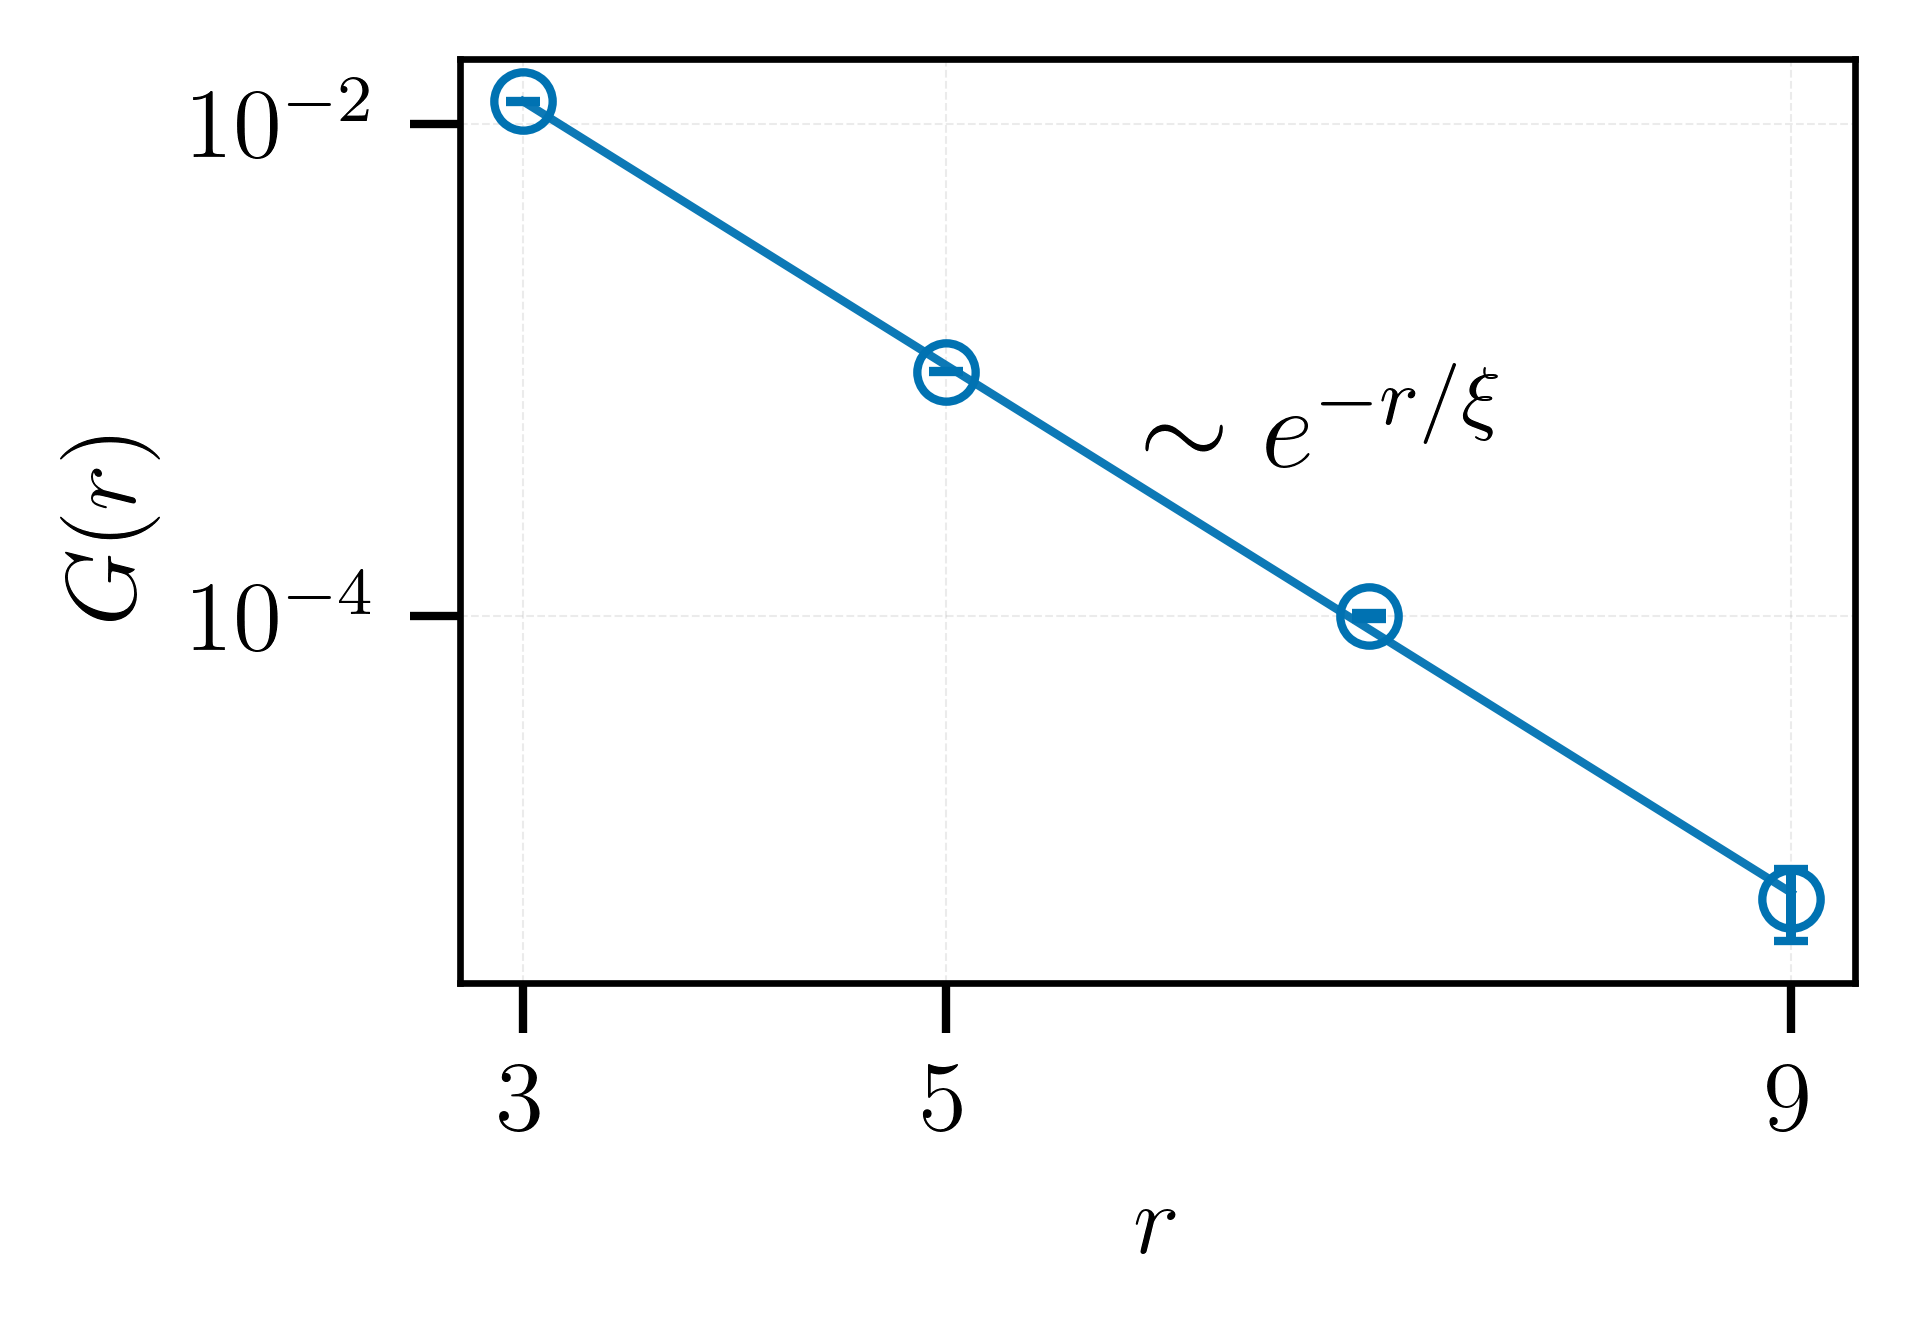

In [4]:
mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"""
\usepackage{amsmath}
\usepackage{amssymb}
"""

plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rc('grid', linestyle='--', alpha=0.25)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linewidth'] = 0.25

LABEL_FSIZE  = 12
TICK_FSIZE   = 12

# ---------------------------------------------------------
# Parameters
# ---------------------------------------------------------
L = 100
SNR_MIN = 3
r_min = 2
r_max = int(np.floor(L / 3))

# --------- x-axis tick control ----------
X_TICKS = None         
# ---------------------------------------------------------
# Load data
# ---------------------------------------------------------
G2     = np.asarray(globals()[f"G2_{L}"], dtype=float)
G2_err = np.asarray(globals()[f"G2_err_{L}"], dtype=float)

# ---------------------------------------------------------
# r selection (odd r only)
# ---------------------------------------------------------
r_all = np.arange(1, len(G2) + 1)
mask  = (r_all % 2 == 1) & (r_all >= r_min) & (r_all <= r_max)

r_odd       = r_all[mask]
G_signed    = G2[r_odd - 1]
G_signed_er = G2_err[r_odd - 1]

# ---------------------------------------------------------
# Compute SNR and apply filter
# ---------------------------------------------------------
SNR_signed = np.zeros_like(G_signed)
ok = (G_signed_er > 0) & np.isfinite(G_signed) & np.isfinite(G_signed_er)
SNR_signed[ok] = np.abs(G_signed[ok]) / G_signed_er[ok]

mask_signed_snr_ok = (SNR_signed >= SNR_MIN) & (np.abs(G_signed) > 0)

r_abs      = r_odd[mask_signed_snr_ok]
G_plot     = np.abs(G_signed[mask_signed_snr_ok])
G_plot_err = G_signed_er[mask_signed_snr_ok]

# ---------------------------------------------------------
# Figure
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(3, 2), dpi=600)

col = "#0072B2"

# C_EA-style markers
eb = ax.errorbar(
    r_abs, G_plot, yerr=G_plot_err,
    fmt='o',
    markersize=7,
    markerfacecolor='none',
    markeredgewidth=1,
    capsize=2,
    elinewidth=1.2,
    capthick=0.7,
    color=col,
    zorder=3
)
eb[0].set_markeredgecolor(col)

# Exponential fit
log_y = np.log(G_plot)
b_e, a_e = np.polyfit(r_abs, log_y, 1)

r_line = np.linspace(r_abs.min(), r_abs.max(), 300)
ax.semilogy(
    r_line,
    np.exp(a_e + b_e * r_line),
    '-',
    lw=1.0,
    color=col,
    alpha=0.95,
    zorder=2
)

# ---------------------------------------------------------
# Labels + annotation
# ---------------------------------------------------------
ax.set_xlabel(r'$r$', fontsize=LABEL_FSIZE)
ax.set_ylabel(r'$G(r)$', fontsize=LABEL_FSIZE)
ax.text(
    0.62, 0.59, r"$\sim e^{-r/\xi}$",
    fontsize=LABEL_FSIZE+2,
    ha="center", va="center",
    transform=ax.transAxes
)

# ---------------------------------------------------------
# Axis scales and ticks
# ---------------------------------------------------------
ax.set_yscale('log')

# y-axis (log with visible minor ticks)
ax.yaxis.set_major_locator(LogLocator(base=10.0))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10) * 0.1))
ax.yaxis.set_major_formatter(LogFormatterMathtext())
ax.yaxis.set_minor_formatter(mpl.ticker.NullFormatter())

ax.minorticks_on()
ax.tick_params(axis='y', which='minor', left=True)
X_TICKS = [3,5,9]

if X_TICKS is not None:
    ax.set_xticks(X_TICKS)
ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
ax.xaxis.set_minor_locator(NullLocator())

# tick styling
ax.tick_params(axis='both', which='major',
               labelsize=TICK_FSIZE, length=6, width=1.0)
ax.tick_params(axis='both', which='minor',
               length=4, width=0.9)

ax.grid(True, which='both', linestyle='--', linewidth=0.25, alpha=0.25)

pdf_name = "Figs/1d-majorana-exp-decay.pdf"
plt.savefig(pdf_name, dpi=600, bbox_inches="tight", pad_inches=0.08)
print(f"Saved high-quality PDF as: {pdf_name}")
plt.show()